In [110]:
import matplotlib.pyplot as plt 
import pandas as pd
import numpy as np
import re

# Week 1 (06-15-26)

## Sample plot: SPARC Galaxies

### Learning Matplotlib and Pandas

This week we are making a rotation curve of the galaxy NGC 3109. We started learning how to handle data in Pandas and plotting the data with matplotlib. 

The first task was to download the dataset from the SPARC website, a .zip file that contained rotation curves for the 175 galaxies in the sample. These are seperate text files with observed velocity and decomposed velocities pertaining to the disk and bulge, as a function of radius. It also has surface brightness profile information, but we are not dealing with that. 

From then, we had to open the data in Python, specifically using **Jupyter Notebook** text editor. 

Useful functions used from Pandas: 

* `read_csv()`

* `DataFrame()`

Difficulties were in setting the correct directory to open the file (Windows issue) but also using the right parameters for `pd.read_csv()`.

We then made the plot for NGC 3109 where we looked at the velocity, gas velocity, and disk velocity, and bulge velocity. There were no measurements for the bulge velocity which makes sense because... We can clearly see the rotation for the stellar matter, do not match observations. The increased velocities 

In [9]:
# Set up the dataframe parameters 

indir = "/Users/silvana/Desktop/mentoria_proyecto/project1/Rotmod_LTG/" # Directory where the files are saved

cols = ["Rad", "Vobs", "errV", "Vgas", "Vdisk", "Vbul", "SBdisk", "SBbul"] # comment :D always comment !!!!

gal = pd.read_csv(indir + "UGC12732_rotmod.dat",comment="#", delim_whitespace=True, names=cols)

In [38]:
# Let's look at the text file :) 

gal

,Rad,Vobs,errV,Vgas,Vdisk,Vbul,SBdisk,SBbul
0,0.26,6.1,1.6,1.00,2.78,0.0,10.55,0.0
1,0.52,11.2,0.7,2.12,4.73,0.0,8.77,0.0
2,0.77,14.9,1.5,4.53,7.00,0.0,8.41,0.0
3,1.03,19.1,2.2,6.54,8.59,0.0,7.93,0.0
4,1.29,24.3,0.9,8.22,10.63,0.0,6.67,0.0
5,1.55,29.8,1.9,10.06,11.72,0.0,5.17,0.0
6,1.81,34.3,1.6,11.73,12.56,0.0,4.71,0.0
7,2.06,38.2,3.5,12.92,13.39,0.0,3.81,0.0
8,2.32,42.5,5.6,13.76,13.69,0.0,2.97,0.0
9,2.58,42.3,3.0,14.44,13.73,0.0,2.43,0.0


In [39]:
# Name the variables of interest, usually it is better to name them so then you can easily access arrays. 

rad = gal['Rad'] #radius in kiloparsec 
vobs = gal['Vobs'] # observed velocity in km/s 
verr = gal['errV'] # error in the observed velocity
vgas = gal["Vgas"]
vdisk = gal["Vdisk"]
vbul = gal["Vbul"]

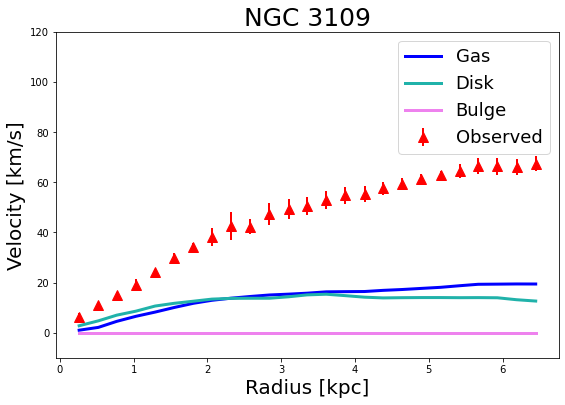

In [40]:
plt.figure(figsize=(9,6))

plt.errorbar(rad, vobs, lw=4,color='red',yerr=verr,elinewidth=2,fmt='^',markersize=10,label='Observed')

plt.plot(rad, vgas,lw=3, color='blue',label="Gas")
plt.plot(rad, vdisk,lw=3,color='lightseagreen',label="Disk")
plt.plot(rad, vbul, color='violet', lw=3,label="Bulge")

plt.xlabel('Radius [kpc]', fontsize=20)
plt.ylabel('Velocity [km/s]', fontsize=20)

plt.title('NGC 3109',fontsize=25)

plt.legend(fontsize=18)
plt.ylim([-10,120])


plt.show()

# Week 2 (06-22-2026)

- Are there any questions from last week? 
- How did journaling/documenting go? **important**
- Did they read astrobites? 
- Did they learn anything new? 

## Exploring SMBH-Galaxy Scaling Relations

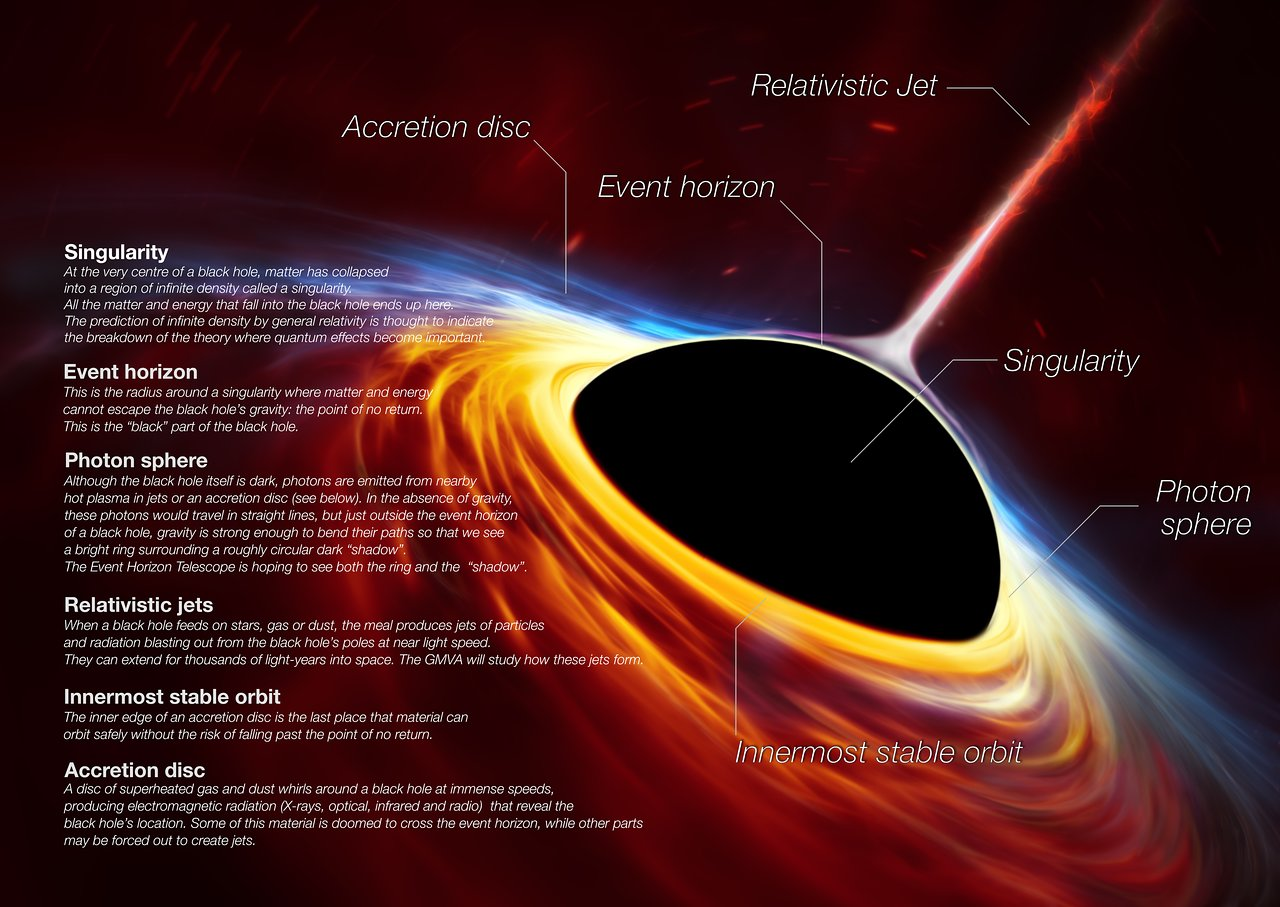

### Project Description 

The purpose of this project is to study black hole–galaxy scaling relations using a published sample of 72 nearby galaxies with measured black hole masses and host-galaxy properties from McConnell & Ma (2013). You will begin by exploring the $M_{\rm BH}-\sigma_\star$ relation, which connects supermassive black hole (SMBH or $M_{BH}$) mass to the stellar velocity dispersion ($\sigma_\star$) of the host galaxy. You will then investigate how black hole mass relates to other galaxy properties, such as luminosity, bulge mass, morphology, or outliers from the main relation. 

The second step is to search in literature for newer SMBH measurements and update the original dataset and plots. Depending on progress, you may explore how dynamical modeling is used to measure black hole masses and use a dynamical modeling code to test the SMBH mass for a galaxy. By the end of the project, you will develop a research question from the data and support your answer with plots and quantitative analysis.

### Goals

**The goal** this week is to do background reading on BH mass measurements, and the connection between BHs and their host galaxies. Additionally, you will make a plot of one of the most famous scaling relations in extragalactic astronomy: the $M_{BH}-\sigma_{\star}$ relation. 

We also want to get more familiarized with useful `Python` tools that will help for data handling in the future! 

### Cheat Sheets: *(feel free to add more!)*

- [Matplotlib colors](https://matplotlib.org/stable/gallery/color/named_colors.html)
- Jupyter [Markdown cheet sheat](https://www.ibm.com/docs/en/watson-studio-local/1.2.3?topic=notebooks-markdown-jupyter-cheatsheet)

### Python things to learn about: 

To learn more about specific functions, can go to this [online tutorial](https://afterhoursprogramming.com/tutorials/python/) which goes through the definitions of basic Python. For `numpy` 

- `for` loops and `while` loops

- `if` statetements 

- `dictionaries`

- Making indexes: [np.arange()](https://numpy.org/doc/stable/reference/generated/numpy.arange.html) and [np.linspace()](https://numpy.org/doc/stable/reference/generated/numpy.linspace.html)

- This is just a useful thing: [np.where()](https://numpy.org/doc/stable/reference/generated/numpy.where.html) 

**REMINDER TO SHOW THEM PYTHON ERRORS! :D**

### Readings for this project: 

**Astrobites+** 

- [Galaxy Classification](https://astrobites.org/guides/galaxy-and-agn-types/)
- [Intro to MBH-sigma](https://astrobites.org/2012/12/05/introducing-the-over-massive-black-hole/)
- [M-sigma relation Wikipedia](https://en.wikipedia.org/wiki/M%E2%80%93sigma_relation)

**Science Articles** (to skim or just have as reference) 
- REVISITING THE SCALING RELATIONS OF BLACK HOLE MASSES AND HOST GALAXY PROPERTIES ([McConnell & Ma 2013](https://ui.adsabs.harvard.edu/abs/2013ApJ...764..184M/abstract))

- Coevolution (Or Not) of Supermassive Black Holes and Host Galaxies ([Kormendy & Ho 2013](https://ui.adsabs.harvard.edu/abs/2013ARA%26A..51..511K/abstract))

- If you like history see [Gebhardt et al. 2002](https://iopscience.iop.org/article/10.1086/312840): A Relationship between Nuclear Black Hole Mass and Galaxy Velocity Dispersion
- More to come... 


**Science articles that Silvana wants to read:**  
- The Assembly of Supermassive Black Holes at z<1 in Early-type Galaxies from Scaling Relations ([Farrah et al. 2026](https://ui.adsabs.harvard.edu/abs/2025ApJ...981...71F/abstract))
- Galaxy and black hole coevolution in dark matter haloes not captured by cosmological simulations ([Yesuf & Bottrell 2026](https://www.nature.com/articles/s41550-026-02792-y)) 
- THE BLACK HOLE MASS IN M87 FROM GEMINI/NIFS ADAPTIVE OPTICS OBSERVATIONS ([Gebhardt et al. 2011](https://iopscience.iop.org/article/10.1088/0004-637X/729/2/119))

### How to make the plot

1. Go to McConnell & Ma 2013 table 3 and take a look at the black hole masses and galaxy properties.** 
2. Download the `.ascii`
3. Plot black hole mass $M_{BH}$ vs. stellar velocity dispersion $\sigma$. **Make three plots:**

    a. A plot of just the black hole masses and velocity dispersions (column 2 and column 3)
    
    b. **One person:** A plot of the above but galaxies are separated by Method (column 11) 
    
    c. **Another person:** A plot of the above but galaxies are separated by Morphological Type (column 10)

# Week 3 (06-29-2026)

- Are there any questions from last week? 
- How did journaling/documenting go?
- Did you learn anything new? 

### Fitting the $M_{\rm BH}$–$\sigma_\star$ Relation

Last week you made your first plots of the $M_{\rm BH}$–$\sigma_\star$ relation, you can clearly see a trend by eye. This week we go further: **we will fit a line to that trend and ask whether the relation changes depending on different properties.**

### Goals

We are going to fit the data using `scipy.stats.linregress` and compare to the fits in the paper. Specifically we will make the three fits they did in **Figure 1**: 

1. The entire sample 
2. Early-type galaxies (red dashed line)
3. Late-type galaxies (blue dot-dashed line)

---

## 💻 Python tools 

| Python tool | Description |
|---|---|
| `scipy.stats.linregress` | Fits a straight line to data, gives you slope, intercept, and $r^2$ |
| `numpy.polyfit` | Another way to fit a polynomial (line = degree 1) |
| `numpy.polyval` | Evaluates a polynomial at new x values — useful for drawing the fit line |

> **Linear Regression:** [`scipy.stats.linregress` documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.linregress.html)'

## 📚Useful Readings 

- Astrobites: [Astrostatistics: How to fit a model to data](https://astrobites.org/2011/07/26/astrostatistics-how-to-fit-a-model-to-data/)

---
## Part 1: A first linear fit to the full sample

### Why log space?

The $M_{\rm BH}$–$\sigma_\star$ relation is a **power law**:

$$M_{\rm BH} = \beta \cdot \sigma_\star^\alpha$$

Taking $\log_{10}$ of both sides turns this into a straight line:

$$\log M_{\rm BH} = \alpha \log \sigma_\star + \log \beta$$

So when we fit a line in log–log space, the **slope is the power-law index** $\alpha$ and the intercept is $\log k$. This is why we always work in log space for scaling relations!

The McConnell & Ma (2013) best fit for the full sample gives roughly $\alpha = 5.64$ and $\beta = 8.32$: 

> $$\log_{10} M_{ \rm BH} = 8.32 + 5.64 \log_{10}(\sigma/200\ {\rm km\ s^{-1}}) $$

for early-type galaxies:

> $$\log_{10} M_{ \rm BH} = 8.39 + 5.20 \log_{10}(\sigma/200\ {\rm km\ s^{-1}}) $$

and for late-type galaxies:

> $$\log_{10} M_{ \rm BH} = 8.07 + 5.06 \log_{10}(\sigma/200\ {\rm km\ s^{-1}}) $$

See if your fit recovers something similar.

# Week 4-5 (07-06-2026) 

## Part 2: Updating the $M_{\rm BH}-\sigma$ Plot with New Values from the MASSIVE Survey

In this part of the project, we will update the original $M_{\rm BH}-\sigma$ relation from McConnell & Ma (2013) by adding newer supermassive black hole mass measurements, especially at the high-mass end. We will focus on recent measurements from the MASSIVE Survey and other massive galaxies with newly reported SMBH masses.

### Paper references

- Big Galaxies and Big Black Holes: The Massive Ends of the Local Stellar and Black Hole Mass Functions and the Implications for Nanohertz Gravitational Waves ([Liepold & Ma 2024](https://iopscience.iop.org/article/10.3847/2041-8213/ad66b8))
- The MASSIVE survey – VIII. Stellar velocity dispersion profiles and environmental dependence of early-type galaxies (Veale et al. 2017)
- Additional recent SMBH measurements:
    - 4C+37.11 (Surti et al. 2024)
    - Holm 15A (Mehrgan et al. 2019)
    - NGC 708 (de Nicola et al. 2024)
    - NGC 315 (Pilawa et al. 2025)

### 1. Create an updated master table

Start with the existing McConnell & Ma (2013) table of nearby galaxies with measured black hole masses and host-galaxy properties. Remove columns that will not be used in this part of the project, such as $M_{\rm bulge}$ and `Ref`.

Your updated table should include the following columns:

- Galaxy name
- Black hole mass, $M_{\rm BH}$
- Uncertainty on $M_{\rm BH}$, if available
- Stellar velocity dispersion, $\sigma_e$
- Morphological type
- Black hole detection method, such as stellar dynamics, gas dynamics, or masers
- Reference for the black hole mass
- Source flag identifying where the galaxy/value comes from

Possible source flags:

- `MM13_original`: galaxy and black hole mass are from McConnell & Ma (2013)
- `MM13_updated`: galaxy appears in McConnell & Ma (2013), but the black hole mass has been updated using a newer measurement
- `LM24_new`: new galaxy or value added from Liepold & Ma (2024)
- `extra_recent`: new galaxy added from another recent paper

### 2. Add new black hole mass measurements from Liepold & Ma (2024)

Add the black hole masses reported in Liepold & Ma (2024).

If a galaxy already appears in McConnell & Ma (2013), update the black hole mass and clearly mark that the value has been updated. Do not overwrite values silently. Keep track of both the original and updated values when possible.

For example, you may want columns such as:

- `M_BH_MM13`
- `M_BH_updated`
- `M_BH_reference`
- `source_flag`

If a galaxy does not appear in McConnell & Ma (2013), add it as a new row and leave unavailable columns blank until you find the missing information.

For each added or updated galaxy, find or record:

- $M_{\rm BH}$ and its uncertainty
- $\sigma_e$, using Veale et al. (2017) when appropriate for MASSIVE galaxies
- morphological type, using the [NASA/IPAC Extragalactic Database](https://ned.ipac.caltech.edu/) when needed
- black hole detection method
- literature reference for the black hole mass

### 3. Add additional recent high-mass SMBH measurements

Add the following galaxies as additional recent measurements and clearly distinguish them in your table:

- 4C+37.11 (Surti et al. 2024)
- Holm 15A (Mehrgan et al. 2019)
- NGC 708 (de Nicola et al. 2024)
- NGC 315 (Pilawa et al. 2025)

For each galaxy, find or record:

- $M_{\rm BH}$ and its uncertainty
- $\sigma_e$
- morphological type
- black hole detection method
- literature reference for the black hole mass

### 4. Update the $M_{\rm BH}-\sigma$ plot

Make an updated $M_{\rm BH}-\sigma$ plot using the combined table.

On the plot, distinguish different galaxy categories using colors, markers, or labels. For example, you may distinguish:

- Original McConnell & Ma (2013) galaxies (don't include black hole masses that are new)
- New MASSIVE Survey galaxies
- Additional recent high-mass SMBH measurements
- Early-type and late-type galaxies
- Maybe: Different black hole detection methods

### 5. Make new linear regression fits

Using the updated table, fit the $M_{\rm BH}-\sigma$ relation in log space.

You may use `scipy.stats.linregress` or `np.polyfit`.

Fit the relation in the form:

$$
\log_{10}\left(\frac{M_{\rm BH}}{M_\odot}\right)
=
\alpha
+
\beta
\log_{10}\left(\frac{\sigma_e}{200 \ {\rm km \ s^{-1}}}\right)
$$

Make simple linear fits for:

- All galaxies
- Early-type galaxies only

For each fit, record:

- number of galaxies used
- slope, $\beta$
- intercept, $\alpha$
- scatter around the relation
- which galaxies or measurements were included

Note: this is a simple linear fit in log space. It is useful for exploring the data, but it does not account for uncertainties in both $M_{\rm BH}$ and $\sigma_e$ or model intrinsic scatter in a publication-level way.

### 6. Compare your fits to McConnell & Ma (2013)

Make a table comparing the published McConnell & Ma (2013) relation to your updated fits.

Your comparison table should include:

- Sample used
- Number of galaxies
- Slope, $\beta$
- Intercept, $\alpha$
- Scatter
- Notes about which galaxies were added or updated

Example table format:

| Sample | Number of galaxies | Intercept $\alpha$ | Slope $\beta$ | Scatter | Notes |
|---|---:|---:|---:|---:|---|
| McConnell & Ma (2013), all galaxies |  |  |  |  | Published relation |
| Updated sample, all galaxies |  |  |  |  | Includes newer MASSIVE/high-mass SMBH measurements |
| Updated sample, early-type galaxies only |  |  |  |  | Excludes late-type galaxies |

Use this comparison to discuss whether adding newer massive-galaxy SMBH measurements changes the $M_{\rm BH}-\sigma$ relation, especially at the high-mass end.

# Week 6

---
## Part 3: Identify outliers

The most interesting galaxies are often the ones that **don't fit the trend**. Let's find them!!

An outlier here means: a galaxy whose measured $M_{\rm BH}$ is much higher or lower than what the best-fit line predicts given its $\sigma_\star$. We call this the **residual**.